In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint
import warnings
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings('ignore')

## 1. Load Data and Embeddings

In [2]:
df = pl.read_parquet("/home/rocminfo/Templates/CyberCerberus/data/merged_final_updated.parquet")
y = df["classification"].to_numpy()

url_embeddings = np.load("/home/rocminfo/Templates/CyberCerberus/weights/url_embeddings.npy")
count_embeddings = np.load("/home/rocminfo/Templates/CyberCerberus/weights/count_vectorizer_embeddings.npy")
tfidf_embeddings = np.load("/home/rocminfo/Templates/CyberCerberus/weights/tfidf_vectorizer_embeddings.npy")
neighbor_embeddings = np.load("/home/rocminfo/Templates/CyberCerberus/weights/neighbor_embeddings.npy")

svd_count = TruncatedSVD(n_components=20, random_state=42)
count_reduced = svd_count.fit_transform(count_embeddings)

svd_tfidf = TruncatedSVD(n_components=20, random_state=42)
tfidf_reduced = svd_tfidf.fit_transform(tfidf_embeddings)

if neighbor_embeddings.shape[1] > 200:
    svd_neighbors = TruncatedSVD(n_components=20, random_state=42)
    neighbor_reduced = svd_neighbors.fit_transform(neighbor_embeddings)
else:
    neighbor_reduced = neighbor_embeddings

X_combined = np.hstack([
    url_embeddings,       
    count_reduced,      
    tfidf_reduced,         
    neighbor_reduced
])

print(f"Combined feature shape: {X_combined.shape}")
print(f"Target distribution: {np.unique(y, return_counts=True)}")

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Combined feature shape: (17348, 124)
Target distribution: (array(['adult', 'good', 'illegal'], dtype=object), array([ 4984, 11728,   636]))
Label mapping: {'adult': np.int64(0), 'good': np.int64(1), 'illegal': np.int64(2)}


## 2. Train-Test Split (80/20, Stratified)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 13878 samples
Test set: 3470 samples


## 3. Model Definitions and Pipelines

In [4]:
models = {
    'SVM (Linear)': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel='linear', class_weight='balanced', random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel='rbf', class_weight='balanced', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
    ])
}

X_train_nb = count_embeddings[train_test_split(np.arange(len(count_embeddings)), test_size=0.2, random_state=42, stratify=y_encoded)[0]]
X_test_nb = count_embeddings[train_test_split(np.arange(len(count_embeddings)), test_size=0.2, random_state=42, stratify=y_encoded)[1]]

models_nb = {
    'Naive Bayes': MultinomialNB()
}

## 4. Cross-Validation with Stratified 10-Fold

In [5]:
n_splits = 5
def evaluate_model_cv(model, X, y, model_name):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    return f1_scores

cv_results = {}
print(f"Performing {n_splits}-fold Stratified Cross-Validation...")

for name, model in models.items():
    scores = evaluate_model_cv(model, X_train, y_train, name)
    cv_results[name] = scores
    print(f"{name}: F1-macro = {scores.mean():.4f} ± {scores.std():.4f}")

for name, model in models_nb.items():
    scores = evaluate_model_cv(model, X_train_nb, y_train, name)
    cv_results[name] = scores
    print(f"{name}: F1-macro = {scores.mean():.4f} ± {scores.std():.4f}")

Performing 5-fold Stratified Cross-Validation...
SVM (Linear): F1-macro = 0.9497 ± 0.0054
SVM (RBF): F1-macro = 0.9380 ± 0.0095
Random Forest: F1-macro = 0.9693 ± 0.0029
Logistic Regression: F1-macro = 0.9471 ± 0.0064
Naive Bayes: F1-macro = 0.8003 ± 0.0255


## 5. Visualization: Cross-Validation Results

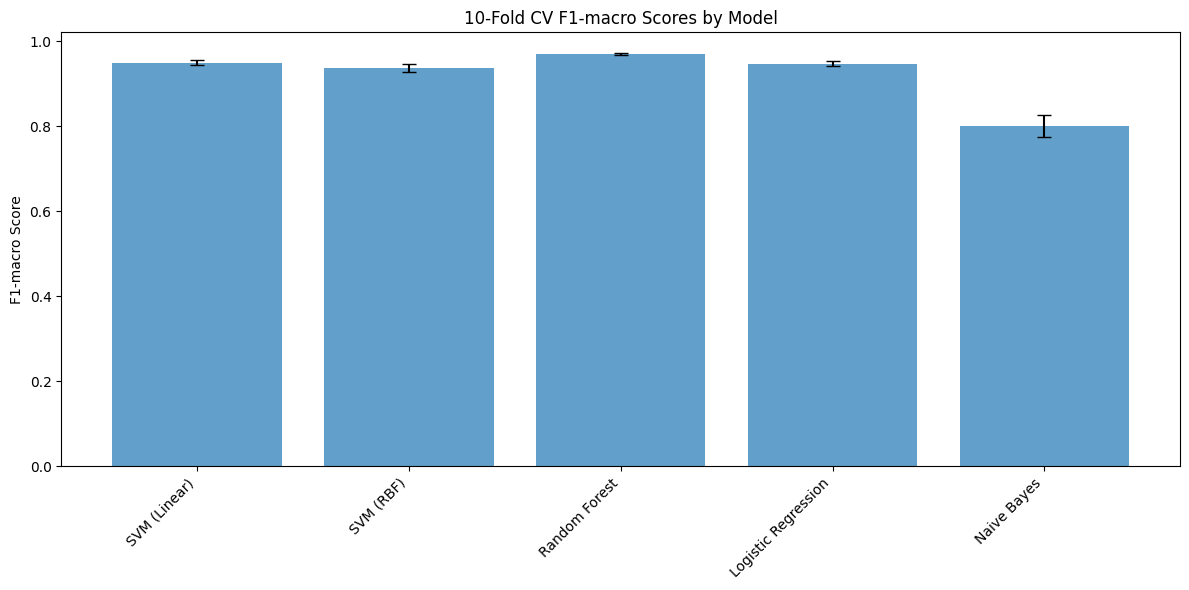

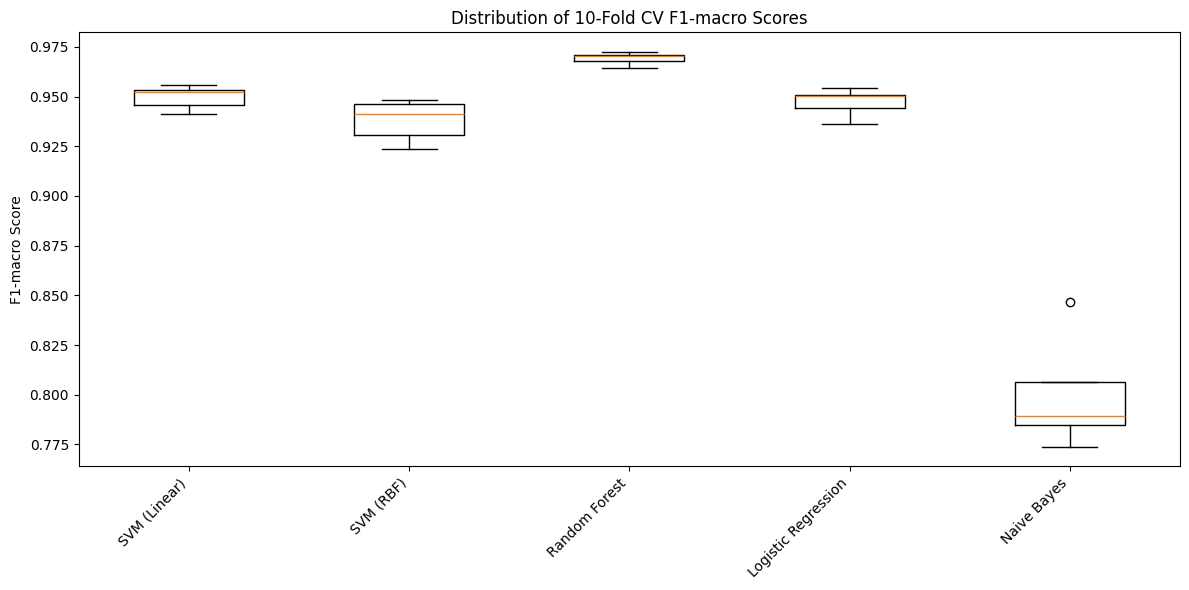

In [6]:
plt.figure(figsize=(12, 6))
model_names = list(cv_results.keys())
means = [cv_results[name].mean() for name in model_names]
stds = [cv_results[name].std() for name in model_names]

plt.bar(model_names, means, yerr=stds, capsize=5, alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1-macro Score')
plt.title('10-Fold CV F1-macro Scores by Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.boxplot([cv_results[name] for name in model_names], labels=model_names)
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1-macro Score')
plt.title('Distribution of 10-Fold CV F1-macro Scores')
plt.tight_layout()
plt.show()

## 6. Final Model Training and Prediction

In [7]:
trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)

for name, model in models_nb.items():
    model.fit(X_train_nb, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_nb)

## 7. Test Set Evaluation

In [ ]:
test_results = {}
for name, pred in predictions.items():
    if name == 'Naive Bayes':
        y_test_actual = y_test
        f1 = f1_score(y_test_actual, pred, average='macro')
    else:
        f1 = f1_score(y_test, pred, average='macro')
    test_results[name] = f1
    print(f"\n{name} - Test F1-macro: {f1:.4f}")
    print(classification_report(y_test_actual if name == 'Naive Bayes' else y_test, 
                              pred, target_names=le.classes_))


SVM (Linear) - Test F1-macro: 0.9521
              precision    recall  f1-score   support

       adult       0.95      0.93      0.94       997
        good       0.97      0.98      0.97      2346
     illegal       0.94      0.94      0.94       127

    accuracy                           0.96      3470
   macro avg       0.96      0.95      0.95      3470
weighted avg       0.96      0.96      0.96      3470


SVM (RBF) - Test F1-macro: 0.9372
              precision    recall  f1-score   support

       adult       0.95      0.93      0.94       997
        good       0.97      0.98      0.97      2346
     illegal       0.89      0.90      0.89       127

    accuracy                           0.96      3470
   macro avg       0.94      0.94      0.94      3470
weighted avg       0.96      0.96      0.96      3470


Random Forest - Test F1-macro: 0.9686
              precision    recall  f1-score   support

       adult       0.97      0.94      0.95       997
        good     

## 8. Confusion Matrices

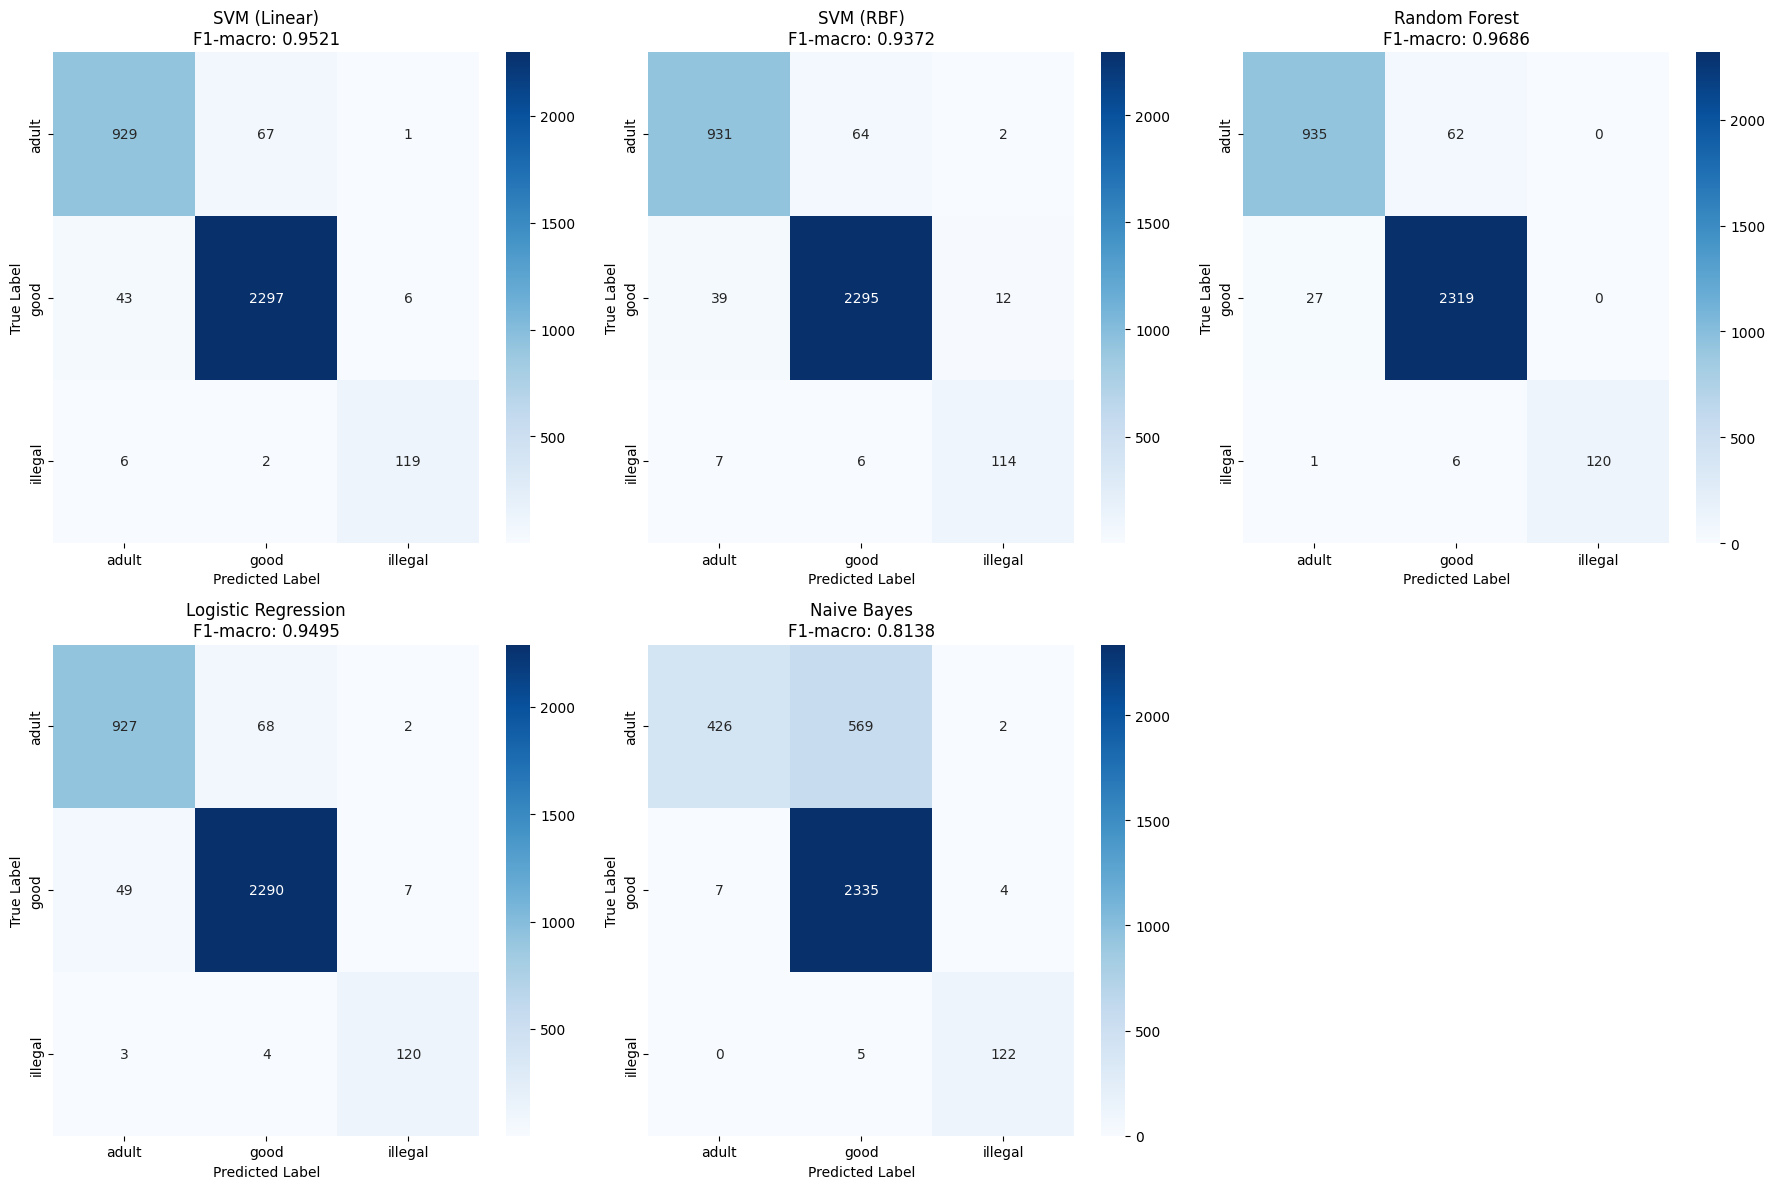

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (name, pred) in enumerate(predictions.items()):
    if idx >= 6:
        break
        
    if name == 'Naive Bayes':
        cm = confusion_matrix(y_test, pred)
    else:
        cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[idx])
    axes[idx].set_title(f'{name}\nF1-macro: {test_results[name]:.4f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

for idx in range(len(predictions), 6):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Detailed Metrics Comparison

In [10]:
metrics_data = []
for name, pred in predictions.items():
    if name == 'Naive Bayes':
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average=None)
        macro_f1 = f1_score(y_test, pred, average='macro')
    else:
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average=None)
        macro_f1 = f1_score(y_test, pred, average='macro')
    
    for i, class_name in enumerate(le.classes_):
        metrics_data.append({
            'Model': name,
            'Class': class_name,
            'Precision': precision[i],
            'Recall': recall[i],
            'F1-score': f1[i]
        })
    metrics_data.append({
        'Model': name,
        'Class': 'Macro Average',
        'Precision': precision.mean(),
        'Recall': recall.mean(),
        'F1-score': macro_f1
    })

metrics_df = pl.DataFrame(metrics_data)
print("\nDetailed Metrics by Model and Class:")
print(metrics_df)


Detailed Metrics by Model and Class:
shape: (20, 5)
┌─────────────────────┬───────────────┬───────────┬──────────┬──────────┐
│ Model               ┆ Class         ┆ Precision ┆ Recall   ┆ F1-score │
│ ---                 ┆ ---           ┆ ---       ┆ ---      ┆ ---      │
│ str                 ┆ str           ┆ f64       ┆ f64      ┆ f64      │
╞═════════════════════╪═══════════════╪═══════════╪══════════╪══════════╡
│ SVM (Linear)        ┆ adult         ┆ 0.949898  ┆ 0.931795 ┆ 0.940759 │
│ SVM (Linear)        ┆ good          ┆ 0.970837  ┆ 0.979113 ┆ 0.974958 │
│ SVM (Linear)        ┆ illegal       ┆ 0.944444  ┆ 0.937008 ┆ 0.940711 │
│ SVM (Linear)        ┆ Macro Average ┆ 0.95506   ┆ 0.949306 ┆ 0.952143 │
│ SVM (RBF)           ┆ adult         ┆ 0.952917  ┆ 0.933801 ┆ 0.943262 │
│ …                   ┆ …             ┆ …         ┆ …        ┆ …        │
│ Logistic Regression ┆ Macro Average ┆ 0.948878  ┆ 0.950267 ┆ 0.949524 │
│ Naive Bayes         ┆ adult         ┆ 0.983834  ┆ 0.42728

## 10. Best Model Selection and Final Results

In [11]:
best_model_name = max(test_results, key=test_results.get)
best_model = trained_models[best_model_name]
best_f1 = test_results[best_model_name]

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"TEST F1-MACRO SCORE: {best_f1:.4f}")
print(f"{'='*60}")

if best_model_name == 'Naive Bayes':
    final_predictions = best_model.predict(X_test_nb)
else:
    final_predictions = best_model.predict(X_test)

final_predictions_labels = le.inverse_transform(final_predictions)
y_test_labels = le.inverse_transform(y_test)

np.save('/home/rocminfo/Templates/CyberCerberus/weights/final_predictions.npy', final_predictions_labels)

print("\nFinal Classification Report:")
print(classification_report(y_test_labels, final_predictions_labels))


BEST MODEL: Random Forest
TEST F1-MACRO SCORE: 0.9686

Final Classification Report:
              precision    recall  f1-score   support

       adult       0.97      0.94      0.95       997
        good       0.97      0.99      0.98      2346
     illegal       1.00      0.94      0.97       127

    accuracy                           0.97      3470
   macro avg       0.98      0.96      0.97      3470
weighted avg       0.97      0.97      0.97      3470



## 11. Model Performance Summary Plot

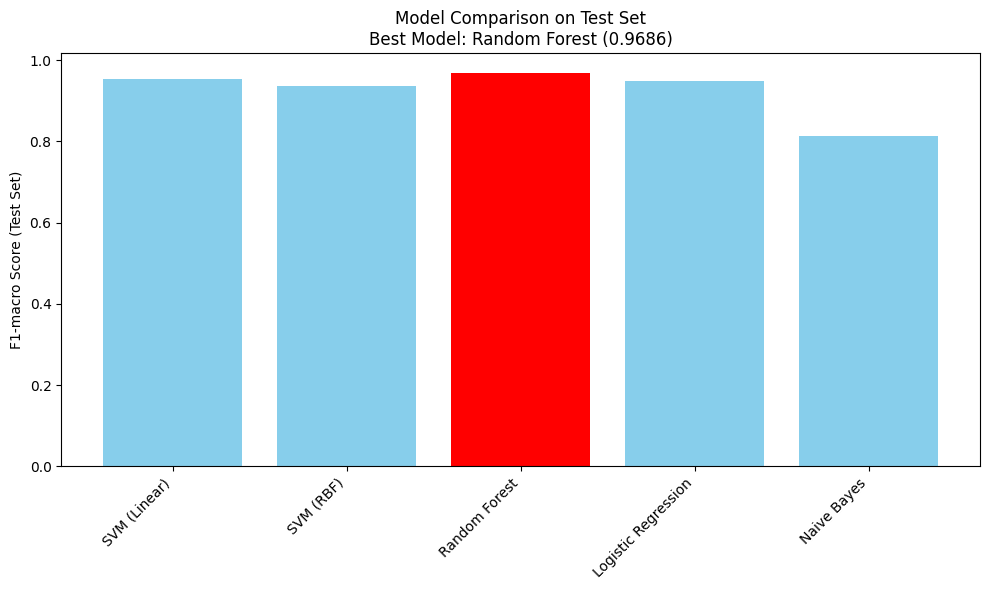

In [12]:
plt.figure(figsize=(10, 6))
model_names_final = list(test_results.keys())
f1_scores_final = list(test_results.values())

colors = ['red' if name == best_model_name else 'skyblue' for name in model_names_final]

plt.bar(model_names_final, f1_scores_final, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1-macro Score (Test Set)')
plt.title(f'Model Comparison on Test Set\nBest Model: {best_model_name} ({best_f1:.4f})')
plt.tight_layout()
plt.show()